# Week 3: Nemotron Nano 4B Experiments (Updated)
**Changes from previous version:**
- Sample size increased from 500 → 5000 rows
- Minimum 10 personas per occupation cutoff applied
- 80/20 train/test split: experiments run on 20% test set only
- All surviving occupations manually audited (yes/no/maybe)
- Verdict encoded as numeric: No=0, Yes=1, Maybe=2
- Histogram to verify yes/no/maybe balance before running experiments

**Devices:**
- Local laptop (RTX 4060, 8GB): Nano 4B
- FDS (RTX 5000 Ada, 32GB): Nano 4B (same model, faster hardware)
- FDS (RTX 5000 Ada, 32GB): Nano 30B (Week 4)

**Baselines (Week 1: associates=college):**
- Random Forest:
- XGBoost: 

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import re
import os

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style="whitegrid")

RESULTS_DIR = "../results"
DATA_DIR    = "../data"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("Imports OK")

Imports OK


## 2. Load Full Dataset and Sample 5000 Rows

In [2]:
print("Loading Nemotron-Personas-USA...")
ds = load_dataset("nvidia/Nemotron-Personas-USA")
df_full = ds["train"].to_pandas()

FEATURES = ["age", "sex", "marital_status", "occupation", "state"]
TARGET   = "education_level"

# Binary label: college = associates + bachelors + graduate
COLLEGE = {"associates", "bachelors", "graduate"}
df_full["label_name"] = df_full[TARGET].apply(lambda x: "college" if x in COLLEGE else "not_college")
df_full["label"]      = df_full["label_name"].map({"college": 1, "not_college": 0})

# Filter to working adults only
df_adults = df_full[
    (df_full["age"] >= 18) &
    (~df_full["occupation"].str.lower().str.strip().str.replace("_", " ").isin([
        "no occupation", "not in workforce", ""
    ])) &
    (df_full["occupation"].notna())
].copy()

print(f"Full dataset (adults only): {len(df_adults):,} rows")

# Sample 5000 rows — stratified by label
df_5000 = df_adults.sample(5000, random_state=42).reset_index(drop=True)
df_5000 = df_5000[FEATURES + ["label_name", "label", TARGET]].copy()

print(f"\n5000-row sample:")
print(f"Label balance: {df_5000['label_name'].value_counts().to_dict()}")
print(f"Unique occupations: {df_5000['occupation'].nunique()}")
df_5000.head(3)

Loading Nemotron-Personas-USA...


Full dataset (adults only): 547,776 rows

5000-row sample:
Label balance: {'not_college': 2746, 'college': 2254}
Unique occupations: 461


,age,sex,marital_status,occupation,state,label_name,label,education_level
0,34,Male,never_married,automotive_body_or_related_repairer,NE,not_college,0,high_school
1,23,Male,never_married,public_relations_specialist,MN,not_college,0,some_college
2,34,Male,never_married,police_officer,CA,college,1,bachelors


## 3. Apply Minimum 10 Personas per Occupation Cutoff

In [3]:
MIN_ROWS = 10

# Count occupation frequency in the 5000-row sample
occ_counts = df_5000["occupation"].value_counts()

print(f"Occupations before cutoff: {len(occ_counts)}")
print(f"Occupations with < {MIN_ROWS} rows: {(occ_counts < MIN_ROWS).sum()}")
print(f"Occupations with >= {MIN_ROWS} rows: {(occ_counts >= MIN_ROWS).sum()}")

# Keep only occupations with 10+ rows
valid_occupations = occ_counts[occ_counts >= MIN_ROWS].index
df_filtered = df_5000[df_5000["occupation"].isin(valid_occupations)].reset_index(drop=True)

print(f"\nRows after cutoff: {len(df_filtered):,} (removed {len(df_5000) - len(df_filtered):,} rows)")
print(f"Surviving occupations: {df_filtered['occupation'].nunique()}")
print(f"Label balance after cutoff: {df_filtered['label_name'].value_counts().to_dict()}")

# Show all surviving occupations with counts
surviving = df_filtered["occupation"].value_counts()
print(f"\nAll {len(surviving)} surviving occupations:")
for i, (occ, count) in enumerate(surviving.items(), 1):
    occ_clean = occ.replace("_", " ").strip()
    print(f"  {i:2d}. {occ_clean} ({count} rows)")

Occupations before cutoff: 461
Occupations with < 10 rows: 331
Occupations with >= 10 rows: 130

Rows after cutoff: 3,861 (removed 1,139 rows)
Surviving occupations: 130
Label balance after cutoff: {'not_college': 2101, 'college': 1760}

All 130 surviving occupations:
   1. manager (115 rows)
   2. retail salesperson (109 rows)
   3. software developer (108 rows)
   4. customer service representative (108 rows)
   5. cashier (93 rows)
   6. elementary or middle school teacher (90 rows)
   7. driver sales worker or truck driver (88 rows)
   8. first line supervisor of retail sales worker (78 rows)
   9. accountant or auditor (76 rows)
  10. construction laborer (73 rows)
  11. laborer or freight stock or material mover (67 rows)
  12. secretary or administrative assistant (58 rows)
  13. janitor or building cleaner (58 rows)
  14. assembler or fabricator (57 rows)
  15. stocker or order filler (54 rows)
  16. production worker (51 rows)
  17. financial manager (45 rows)
  18. sales repr

## 4. Occupation Frequency Histogram

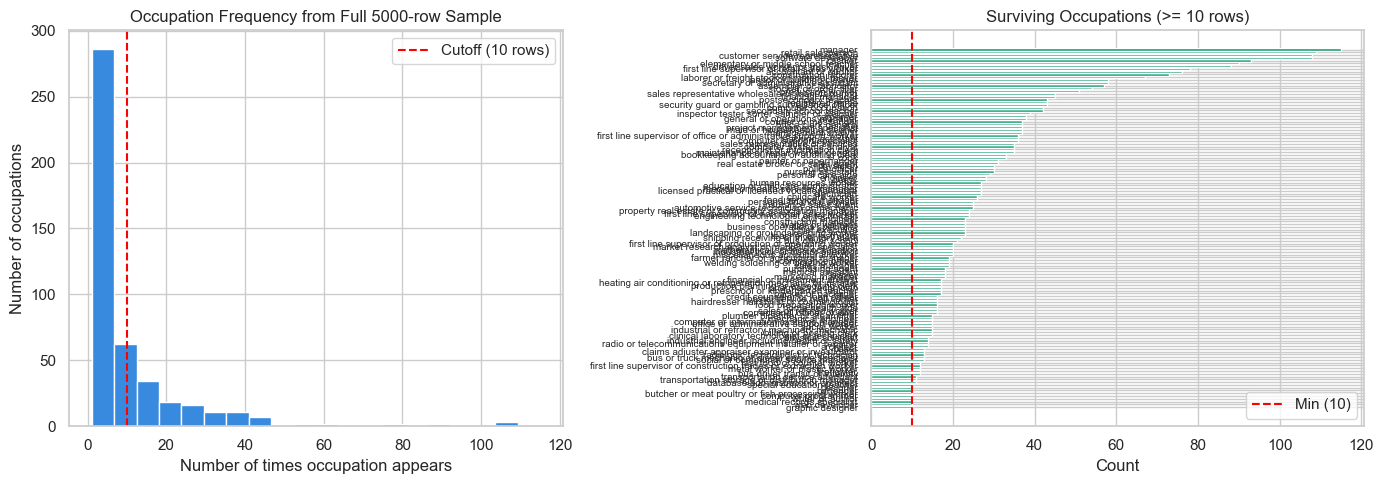

Saved: results/occupation_frequency_histogram.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all occupations in 5000-row sample
all_counts = df_5000["occupation"].value_counts()
axes[0].hist(all_counts.values, bins=20, color="#378ADD", edgecolor="white")
axes[0].axvline(x=MIN_ROWS, color="red", linestyle="--", label=f"Cutoff ({MIN_ROWS} rows)")
axes[0].set_title("Occupation Frequency from Full 5000-row Sample")
axes[0].set_xlabel("Number of times occupation appears")
axes[0].set_ylabel("Number of occupations")
axes[0].legend()

# Bar chart of surviving occupations
surviving_df = surviving.reset_index()
surviving_df.columns = ["occupation", "count"]
surviving_df["occupation"] = surviving_df["occupation"].str.replace("_", " ").str.strip()
surviving_df = surviving_df.sort_values("count", ascending=True)

axes[1].barh(surviving_df["occupation"], surviving_df["count"], color="#1D9E75")
axes[1].axvline(x=MIN_ROWS, color="red", linestyle="--", label=f"Min ({MIN_ROWS})")
axes[1].set_title(f"Surviving Occupations (>= {MIN_ROWS} rows)")
axes[1].set_xlabel("Count")
axes[1].tick_params(axis="y", labelsize=7)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/occupation_frequency_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/occupation_frequency_histogram.png")

## 5. Manual Audit: All Surviving Occupations

Look at the surviving occupations printed in Cell 3 and fill in the dictionary below.

**Categories:**
- `"yes"`: clearly requires a college degree
- `"no"`: clearly does not require a college degree
- `"maybe"`: ambiguous, could go either way

**Numeric encoding (used in analysis):**
- `no` → 0
- `yes` → 1
- `maybe` → 2

In [5]:
# ── FILL THIS IN AFTER RUNNING CELL 3 ────────────────────────────────
# Use the exact occupation names printed in Cell 3
# (with underscores replaced by spaces, all lowercase)

occupation_audit = {
    # Paste your surviving occupations here, one per line:
    # "occupation name": "yes/no/maybe",

    # Pre-filled from previous audit (update if occupation appears again):
    "advertising or promotions manager":                                          "yes",
    "animal trainer":                                                             "no",
    "barber":                                                                     "no",
    "budget analyst":                                                             "yes",
    "chief executive":                                                            "yes",
    "chiropractor":                                                               "yes",
    "compliance officer":                                                         "maybe",
    "construction equipment operator":                                            "no",
    "credit counselor or loan officer":                                           "maybe",
    "customer service representative":                                            "no",
    "dental or ophthalmic laboratory technician or medical appliance technician": "maybe",
    "designer":                                                                   "maybe",
    "fast food or counter worker":                                                "no",
    "first line supervisor of housekeeping or janitorial worker":                 "no",
    "industrial truck or tractor operator":                                       "no",
    "information security analyst":                                               "yes",
    "inspector tester sorter sampler or weigher":                                 "no",
    "laundry or dry cleaning worker":                                             "no",
    "mechanical engineer":                                                        "yes",
    "office clerk general":                                                       "no",
    "pharmacist":                                                                 "yes",
    "physical therapist":                                                         "yes",
    "preschool or kindergarten teacher":                                          "yes",
    "reservation or transportation ticket agent or travel clerk":                 "no",
    "social or human service assistant":                                          "maybe",
    "surgical technologist":                                                      "yes",
    "teacher or instructor":                                                      "yes",
    "training or development specialist":                                         "maybe",
    "weigher measurer checker or sampler recordkeeping":                          "no",
    "wholesale or retail buyer":                                                  "maybe",
}

print(f"Audited: {len(occupation_audit)} occupations")

# Check how many surviving occupations still need to be audited
audit_normalized = {k.lower(): v for k, v in occupation_audit.items()}
surviving_clean  = [o.replace("_", " ").strip().lower() for o in surviving.index]
missing = [o for o in surviving_clean if o not in audit_normalized]

if missing:
    print(f"\n⚠ {len(missing)} surviving occupations NOT yet audited:")
    for m in missing:
        print(f"  - {m}")
    print("\nAdd these to occupation_audit above, then re-run this cell.")
else:
    print("✓ All surviving occupations are audited — run Cell 6.")

Audited: 30 occupations

⚠ 118 surviving occupations NOT yet audited:
  - manager
  - retail salesperson
  - software developer
  - cashier
  - elementary or middle school teacher
  - driver sales worker or truck driver
  - first line supervisor of retail sales worker
  - accountant or auditor
  - construction laborer
  - laborer or freight stock or material mover
  - secretary or administrative assistant
  - janitor or building cleaner
  - assembler or fabricator
  - stocker or order filler
  - production worker
  - financial manager
  - sales representative wholesale or manufacturing
  - registered nurse
  - postsecondary teacher
  - security guard or gambling surveillance officer
  - secondary school teacher
  - computer occupation
  - general or operations manager
  - carpenter
  - courier or messenger
  - project management specialist
  - management analyst
  - maid or housekeeping cleaner
  - teaching assistant
  - first line supervisor of office or administrative support worker


## 6. Balance Check: Yes / No / Maybe Histogram

⚠ 3522 rows still unaudited — complete Cell 5 first.

Verdict distribution (rows):
audit_verdict
no       216
yes       78
maybe     45
Name: count, dtype: int64

Verdict distribution (%):
audit_verdict
no       63.7
yes      23.0
maybe    13.3
Name: proportion, dtype: float64


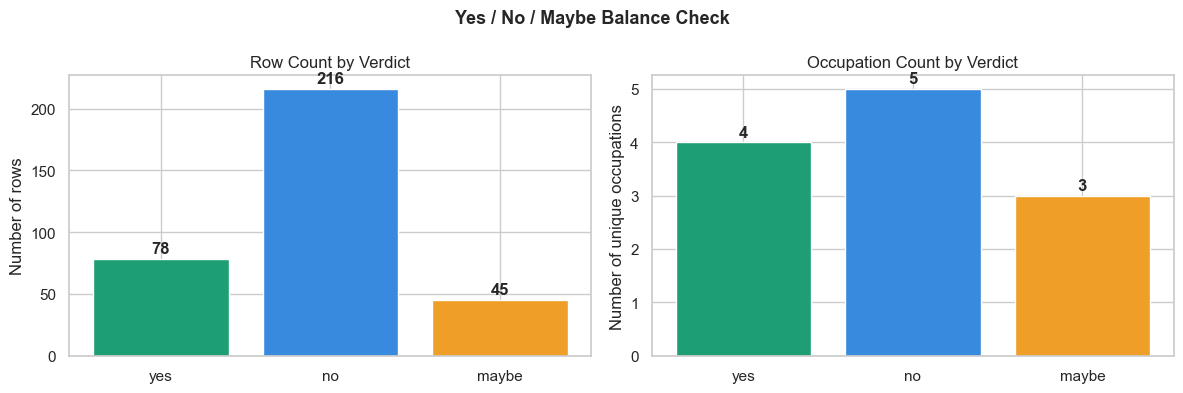

Saved: results/verdict_balance_check.png

=== BALANCE DECISION ===
  Yes:   23%
  No:    64%
  Maybe: 13%
✓ Balanced — safe to proceed with 80/20 split.


In [6]:
# Map verdicts to filtered dataset
df_filtered["occ_clean"]      = df_filtered["occupation"].str.replace("_", " ").str.strip().str.lower()
df_filtered["audit_verdict"]  = df_filtered["occ_clean"].map(audit_normalized)

# Numeric encoding: no=0, yes=1, maybe=2
verdict_map = {"no": 0, "yes": 1, "maybe": 2}
df_filtered["verdict_num"] = df_filtered["audit_verdict"].map(verdict_map)

unaudited = df_filtered["audit_verdict"].isna().sum()
if unaudited > 0:
    print(f"⚠ {unaudited} rows still unaudited — complete Cell 5 first.")
else:
    print("✓ All rows have audit verdicts")

print(f"\nVerdict distribution (rows):")
print(df_filtered["audit_verdict"].value_counts())
print(f"\nVerdict distribution (%):")
print(df_filtered["audit_verdict"].value_counts(normalize=True).round(3) * 100)

# Histogram of verdict distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By row count
vc = df_filtered["audit_verdict"].value_counts().reindex(["yes", "no", "maybe"], fill_value=0)
colors = ["#1D9E75", "#378ADD", "#EF9F27"]
axes[0].bar(vc.index, vc.values, color=colors)
axes[0].set_title("Row Count by Verdict")
axes[0].set_ylabel("Number of rows")
for i, val in enumerate(vc.values):
    axes[0].text(i, val + 5, str(val), ha="center", fontweight="bold")

# By occupation count
occ_verdicts = df_filtered.drop_duplicates("occupation")["audit_verdict"].value_counts().reindex(
    ["yes", "no", "maybe"], fill_value=0
)
axes[1].bar(occ_verdicts.index, occ_verdicts.values, color=colors)
axes[1].set_title("Occupation Count by Verdict")
axes[1].set_ylabel("Number of unique occupations")
for i, val in enumerate(occ_verdicts.values):
    axes[1].text(i, val + 0.1, str(val), ha="center", fontweight="bold")

plt.suptitle("Yes / No / Maybe Balance Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/verdict_balance_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/verdict_balance_check.png")

# Decision
yes_pct   = vc.get("yes",   0) / vc.sum() * 100
no_pct    = vc.get("no",    0) / vc.sum() * 100
maybe_pct = vc.get("maybe", 0) / vc.sum() * 100

print(f"\n=== BALANCE DECISION ===")
print(f"  Yes:   {yes_pct:.0f}%")
print(f"  No:    {no_pct:.0f}%")
print(f"  Maybe: {maybe_pct:.0f}%")
if yes_pct >= 20 and no_pct >= 20 and maybe_pct >= 10:
    print("✓ Balanced — safe to proceed with 80/20 split.")
else:
    print("⚠ Not balanced enough — discuss with advisor.")

## 7. 80/20 Train / Test Split

In [7]:
# 80% train (for future fine-tuning), 20% test (for Nemotron experiments)
df_train, df_test = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42,
    stratify=df_filtered["label"]
)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train set: {len(df_train):,} rows (80%)")
print(f"Test set:  {len(df_test):,} rows (20%)")
print(f"\nTest set label balance:")
print(df_test["label_name"].value_counts())
print(f"\nTest set verdict balance:")
print(df_test["audit_verdict"].value_counts())

# Save both splits
df_train.to_csv(f"{DATA_DIR}/week3_train_5000.csv", index=False)
df_test.to_csv(f"{DATA_DIR}/week3_test_5000.csv",  index=False)
print(f"\nSaved: data/week3_train_5000.csv ({len(df_train):,} rows)")
print(f"Saved: data/week3_test_5000.csv ({len(df_test):,} rows)")

Train set: 3,088 rows (80%)
Test set:  773 rows (20%)

Test set label balance:
label_name
not_college    421
college        352
Name: count, dtype: int64

Test set verdict balance:
audit_verdict
no       43
yes      13
maybe     7
Name: count, dtype: int64

Saved: data/week3_train_5000.csv (3,088 rows)
Saved: data/week3_test_5000.csv (773 rows)


## 8. Helper Functions

In [8]:
OLLAMA_URL = "http://localhost:11434/v1/chat/completions"
MODEL_NAME = "nemotron-3-nano:4b"

SYSTEM_PROMPT = """You are an education level classifier. Given a person's demographic information,
predict whether they are college-educated (have a bachelor's degree or higher) or not.
Think step by step, then respond with ONLY one of these two labels on the final line: college or not_college."""


def serialize_row(row):
    return (
        f"A {int(row['age'])}-year-old {str(row['sex']).lower().strip()}, "
        f"{str(row['marital_status']).replace('_', ' ').strip()}, "
        f"working as a {str(row['occupation']).replace('_', ' ').strip()}. "
        f"Located in {str(row['state']).strip()}."
    )


def build_zero_shot_prompt(row):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Classify this person's education level:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def build_few_shot_prompt(row, examples):
    example_text = ""
    for ex in examples:
        example_text += f"Person: {serialize_row(ex)}\nLabel: {ex['label_name']}\n\n"
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Here are some labeled examples:\n\n{example_text}"
            f"Now classify this person:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def parse_response(content):
    think_match = re.search(r"<think>(.*?)</think>", content, re.DOTALL)
    trace = think_match.group(1).strip() if think_match else ""
    label_match = re.search(r"\b(not_college|college)\b", content, re.IGNORECASE)
    label = label_match.group(1).lower() if label_match else "UNKNOWN"
    return label, trace


def classify_row(messages, timeout=120):
    payload = {
        "model": MODEL_NAME,
        "messages": messages,
        "max_tokens": 1024,
        "temperature": 0.1,
        "stream": False,
        "options": {"num_ctx": 4096},
    }
    start = time.time()
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=timeout).json()
        elapsed  = time.time() - start
        content  = response["choices"][0]["message"]["content"]
        tokens   = response.get("usage", {}).get("completion_tokens", 0)
        label, trace = parse_response(content)
    except Exception as e:
        elapsed = time.time() - start
        label, trace, tokens, content = "ERROR", str(e), 0, str(e)
    return {"label": label, "trace": trace, "raw": content,
            "time_ms": round(elapsed * 1000), "tokens": tokens}


print(f"Model: {MODEL_NAME}")

# Verify Ollama
try:
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    models = [m["name"] for m in r.json().get("models", [])]
    print(f"Ollama running. Models: {models}")
    print(f"Target model present: {MODEL_NAME in models}")
except Exception as e:
    print(f"Ollama not reachable: {e}")

Model: nemotron-3-nano:4b
Ollama running. Models: ['hf.co/nvidia/NVIDIA-Nemotron-3-Nano-4B-GGUF:latest', 'nemotron-3-nano:4b', 'nemotron-mini:latest']
Target model present: True


## 9. Few-shot Example Pool
Must come from **audited occupations only** — sampled from train set.

In [9]:
# Few-shot examples — ONLY from audited occupations in train set
audited_train = df_train[df_train["audit_verdict"].notna()]

print(f"Audited rows in train set: {len(audited_train)}")
print(f"  College: {len(audited_train[audited_train['label_name'] == 'college'])}")
print(f"  Not college: {len(audited_train[audited_train['label_name'] == 'not_college'])}")
print()

fs_college = audited_train[audited_train["label_name"] == "college"].sample(3, random_state=1)
fs_not     = audited_train[audited_train["label_name"] == "not_college"].sample(2, random_state=1)
few_shot_examples = pd.concat([fs_college, fs_not]).sample(frac=1, random_state=1).to_dict("records")

print("Few-shot examples (audited occupations only):")
for ex in few_shot_examples:
    verdict = audit_normalized.get(ex["occupation"].replace("_", " ").strip().lower(), "unaudited")
    print(f"  {serialize_row(ex)} → {ex['label_name']} [{verdict}]")

Audited rows in train set: 276
  College: 115
  Not college: 161

Few-shot examples (audited occupations only):
  A 53-year-old male, never married, working as a office clerk general. Located in PA. → college [no]
  A 64-year-old male, married present, working as a compliance officer. Located in OR. → college [maybe]
  A 64-year-old female, married present, working as a inspector tester sorter sampler or weigher. Located in NY. → not_college [no]
  A 47-year-old male, married present, working as a compliance officer. Located in TN. → college [maybe]
  A 27-year-old male, never married, working as a industrial truck or tractor operator. Located in GA. → not_college [no]


## 10. Evaluation Helper

In [10]:
label_map = {"college": 1, "not_college": 0}

def evaluate_llm_results(results_df, run_name):
    valid = results_df[results_df["pred_label"].isin(["college", "not_college"])].copy()
    unknown_count = len(results_df) - len(valid)
    y_true = valid["true_label"].map(label_map)
    y_pred = valid["pred_label"].map(label_map)
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average="macro")
    auc  = roc_auc_score(y_true, y_pred)
    avg_ms = results_df["time_ms"].mean()
    print(f"\n{'='*50}\n  {run_name}\n{'='*50}")
    print(f"  Rows evaluated: {len(valid)} / {len(results_df)}")
    print(f"  Unknown:        {unknown_count}")
    print(f"  Accuracy:       {acc:.4f}")
    print(f"  Macro F1:       {f1:.4f}")
    print(f"  AUC-ROC:        {auc:.4f}")
    print(f"  Avg time/row:   {avg_ms:.0f}ms")
    print()
    print(classification_report(y_true, y_pred, target_names=["not_college", "college"]))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["not_college", "college"]).plot(ax=ax, colorbar=False)
    ax.set_title(run_name)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/cm_{run_name.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()
    return {"model": run_name, "accuracy": round(acc, 4), "macro_f1": round(f1, 4),
            "auc_roc": round(auc, 4), "ms_per_row": round(avg_ms, 1),
            "unknown": unknown_count, "n_samples": len(valid),
            "week": 3, "device": "local-rtx4060",
            "dataset": "nvidia/Nemotron-Personas-USA"}

all_results = []
print("evaluate_llm_results() defined.")

evaluate_llm_results() defined.


## 11. Experiment A: Zero-shot

In [11]:
print(f"Starting zero-shot on {len(df_test)} test rows...")
print(f"Estimated time: ~{len(df_test) * 4 / 60:.0f} minutes\n")

zs_results = []
t_start = time.time()

for i, row in df_test.iterrows():
    messages = build_zero_shot_prompt(row.to_dict())
    result   = classify_row(messages)
    zs_results.append({
        "row_id":        i,
        "input":         serialize_row(row.to_dict()),
        "occupation":    row["occupation"].replace("_", " ").strip(),
        "audit_verdict": row["audit_verdict"],
        "verdict_num":   row["verdict_num"],
        "true_label":    row["label_name"],
        "pred_label":    result["label"],
        "correct":       result["label"] == row["label_name"],
        "time_ms":       result["time_ms"],
        "tokens":        result["tokens"],
        "trace":         result["trace"],
        "raw":           result["raw"],
    })
    if (i + 1) % 100 == 0:
        elapsed   = time.time() - t_start
        done      = len(zs_results)
        remaining = (elapsed / done) * (len(df_test) - done)
        print(f"  Row {done:4d}/{len(df_test)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

zs_df = pd.DataFrame(zs_results)
zs_df.to_csv(f"{RESULTS_DIR}/week3_zeroshot_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week3_zeroshot_raw.csv")

Starting zero-shot on 773 test rows...
Estimated time: ~52 minutes

  Row  100/773 | Elapsed: 6.2min | Remaining: ~42.0min
  Row  200/773 | Elapsed: 12.5min | Remaining: ~35.7min
  Row  300/773 | Elapsed: 18.8min | Remaining: ~29.6min
  Row  400/773 | Elapsed: 25.1min | Remaining: ~23.4min
  Row  500/773 | Elapsed: 31.5min | Remaining: ~17.2min
  Row  600/773 | Elapsed: 37.9min | Remaining: ~10.9min
  Row  700/773 | Elapsed: 44.4min | Remaining: ~4.6min

Done! Total time: 49.3 minutes
Saved: results/week3_zeroshot_raw.csv


## 12. Zero-shot Results


  Nano 4B zero-shot
  Rows evaluated: 773 / 773
  Unknown:        0
  Accuracy:       0.6339
  Macro F1:       0.6071
  AUC-ROC:        0.6155
  Avg time/row:   3823ms

              precision    recall  f1-score   support

 not_college       0.62      0.82      0.71       421
     college       0.66      0.41      0.50       352

    accuracy                           0.63       773
   macro avg       0.64      0.62      0.61       773
weighted avg       0.64      0.63      0.62       773



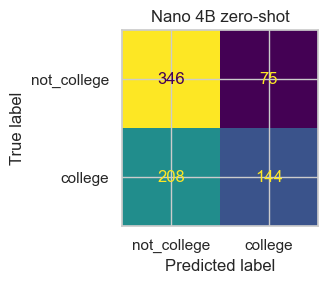

In [12]:
zs_metrics = evaluate_llm_results(zs_df, "Nano 4B zero-shot")
all_results.append(zs_metrics)

## 13. Experiment B — Few-shot
> **Expected time:** ~{test rows} × 6s.

In [13]:
print(f"Starting few-shot on {len(df_test)} test rows...")
print(f"Estimated time: ~{len(df_test) * 6 / 60:.0f} minutes\n")

fs_results = []
t_start = time.time()

for i, row in df_test.iterrows():
    messages = build_few_shot_prompt(row.to_dict(), few_shot_examples)
    result   = classify_row(messages)
    fs_results.append({
        "row_id":        i,
        "input":         serialize_row(row.to_dict()),
        "occupation":    row["occupation"].replace("_", " ").strip(),
        "audit_verdict": row["audit_verdict"],
        "verdict_num":   row["verdict_num"],
        "true_label":    row["label_name"],
        "pred_label":    result["label"],
        "correct":       result["label"] == row["label_name"],
        "time_ms":       result["time_ms"],
        "tokens":        result["tokens"],
        "trace":         result["trace"],
        "raw":           result["raw"],
    })
    if (i + 1) % 100 == 0:
        elapsed   = time.time() - t_start
        done      = len(fs_results)
        remaining = (elapsed / done) * (len(df_test) - done)
        print(f"  Row {done:4d}/{len(df_test)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

fs_df = pd.DataFrame(fs_results)
fs_df.to_csv(f"{RESULTS_DIR}/week3_fewshot_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week3_fewshot_raw.csv")

Starting few-shot on 773 test rows...
Estimated time: ~77 minutes

  Row  100/773 | Elapsed: 12.4min | Remaining: ~83.5min
  Row  200/773 | Elapsed: 24.9min | Remaining: ~71.4min
  Row  300/773 | Elapsed: 36.8min | Remaining: ~58.0min
  Row  400/773 | Elapsed: 49.2min | Remaining: ~45.9min
  Row  500/773 | Elapsed: 61.9min | Remaining: ~33.8min
  Row  600/773 | Elapsed: 75.3min | Remaining: ~21.7min
  Row  700/773 | Elapsed: 88.3min | Remaining: ~9.2min

Done! Total time: 98.5 minutes
Saved: results/week3_fewshot_raw.csv


## 14. Few-shot Results


  Nano 4B few-shot
  Rows evaluated: 770 / 773
  Unknown:        3
  Accuracy:       0.6571
  Macro F1:       0.6557
  AUC-ROC:        0.6686
  Avg time/row:   7642ms

              precision    recall  f1-score   support

 not_college       0.76      0.54      0.63       420
     college       0.59      0.79      0.68       350

    accuracy                           0.66       770
   macro avg       0.68      0.67      0.66       770
weighted avg       0.68      0.66      0.65       770



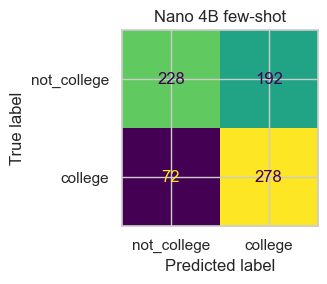

In [14]:
fs_metrics = evaluate_llm_results(fs_df, "Nano 4B few-shot")
all_results.append(fs_metrics)

## 15. Accuracy by Occupation Difficulty (Yes / No / Maybe)

=== ACCURACY BY OCCUPATION DIFFICULTY ===

YES (13 rows):
  Zero-shot: 69.2%
  Few-shot:  76.9%
  Top occs:  ['teacher or instructor', 'preschool or kindergarten teacher', 'mechanical engineer']

NO (43 rows):
  Zero-shot: 74.4%
  Few-shot:  67.4%
  Top occs:  ['customer service representative', 'inspector tester sorter sampler or weigher', 'industrial truck or tractor operator']

MAYBE (7 rows):
  Zero-shot: 42.9%
  Few-shot:  57.1%
  Top occs:  ['credit counselor or loan officer', 'compliance officer', 'designer']


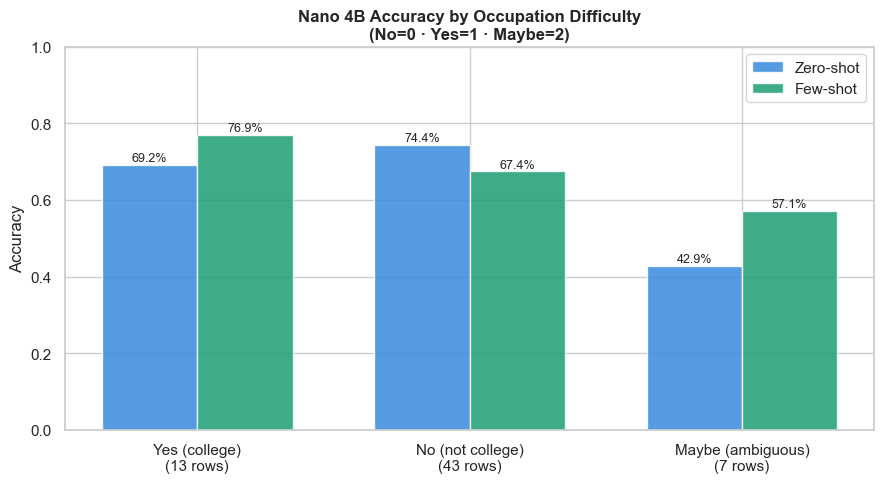

Saved: results/week3_accuracy_by_difficulty.png


In [15]:
verdict_labels = ["yes", "no", "maybe"]
verdict_names  = ["Yes (college)", "No (not college)", "Maybe (ambiguous)"]
zs_accs, fs_accs, sizes = [], [], []

print("=== ACCURACY BY OCCUPATION DIFFICULTY ===")
for verdict in verdict_labels:
    zs_sub   = zs_df[zs_df["audit_verdict"] == verdict]
    fs_sub   = fs_df[fs_df["audit_verdict"] == verdict]
    zs_valid = zs_sub[zs_sub["pred_label"].isin(["college", "not_college"])]
    fs_valid = fs_sub[fs_sub["pred_label"].isin(["college", "not_college"])]
    zs_acc   = (zs_valid["pred_label"] == zs_valid["true_label"]).mean() if len(zs_valid) > 0 else 0
    fs_acc   = (fs_valid["pred_label"] == fs_valid["true_label"]).mean() if len(fs_valid) > 0 else 0
    zs_accs.append(zs_acc)
    fs_accs.append(fs_acc)
    sizes.append(len(zs_sub))
    top_occs = zs_sub["occupation"].value_counts().head(3).index.tolist()
    print(f"\n{verdict.upper()} ({len(zs_sub)} rows):")
    print(f"  Zero-shot: {zs_acc:.1%}")
    print(f"  Few-shot:  {fs_acc:.1%}")
    print(f"  Top occs:  {top_occs}")

# Bar chart
x = range(3)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], zs_accs, width, label="Zero-shot", color="#378ADD", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], fs_accs, width, label="Few-shot",  color="#1D9E75", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{n}\n({s} rows)" for n, s in zip(verdict_names, sizes)])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Nano 4B Accuracy by Occupation Difficulty\n(No=0 · Yes=1 · Maybe=2)",
             fontsize=12, fontweight="bold")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week3_accuracy_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week3_accuracy_by_difficulty.png")

## 16. K-Means Cluster Analysis

In [17]:
cluster_features = ["age", "sex", "marital_status", "occupation", "state"]
X_cluster = df_test[cluster_features].copy()

le_dict = {}
for col in ["sex", "marital_status", "occupation", "state"]:
    le = LabelEncoder()
    X_cluster[col] = le.fit_transform(X_cluster[col].astype(str))
    le_dict[col] = le

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

K  = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels_arr = km.fit_predict(X_scaled)

zs_df["cluster"] = cluster_labels_arr
fs_df["cluster"] = cluster_labels_arr

cluster_stats = []
for c in range(K):
    zs_rows  = zs_df[zs_df["cluster"] == c]
    fs_rows  = fs_df[fs_df["cluster"] == c]
    zs_valid = zs_rows[zs_rows["pred_label"].isin(["college", "not_college"])]
    fs_valid = fs_rows[fs_rows["pred_label"].isin(["college", "not_college"])]
    zs_acc   = (zs_valid["pred_label"] == zs_valid["true_label"]).mean()
    fs_acc   = (fs_valid["pred_label"] == fs_valid["true_label"]).mean()
    size     = len(zs_rows)
    college_rate = (zs_rows["true_label"] == "college").mean()
    cluster_ids  = zs_rows["row_id"].values
    top_occ      = df_test.loc[df_test.index.isin(cluster_ids), "occupation"].value_counts().head(3).index.tolist()
    avg_age      = df_test.loc[df_test.index.isin(cluster_ids), "age"].mean()
    verdicts     = zs_rows["audit_verdict"].dropna()
    dominant     = verdicts.value_counts().idxmax() if len(verdicts) > 0 else "unaudited"
    top_occ_str  = ", ".join(top_occ)

    cluster_stats.append({
        "cluster":          c,
        "size":             size,
        "zs_accuracy":      round(zs_acc, 3),
        "fs_accuracy":      round(fs_acc, 3),
        "college_rate":     round(college_rate, 3),
        "avg_age":          round(avg_age, 1),
        "dominant_verdict": dominant,
        "top_occupations":  top_occ_str,
    })

    print(f"\n── Cluster {c} ─────────────────────────────────────────")
    print(f"  Size:               {size} rows")
    print(f"  Zero-shot accuracy: {zs_acc:.1%}")
    print(f"  Few-shot accuracy:  {fs_acc:.1%}")
    print(f"  College rate:       {college_rate:.1%}")
    print(f"  Avg age:            {avg_age:.1f}")
    print(f"  Dominant verdict:   {dominant}")
    print(f"  Top occupations:    {top_occ_str}")

cluster_df = pd.DataFrame(cluster_stats)
cluster_df.to_csv(f"{RESULTS_DIR}/week3_cluster_analysis.csv", index=False)
print("\nSaved: results/week3_cluster_analysis.csv")


── Cluster 0 ─────────────────────────────────────────
  Size:               191 rows
  Zero-shot accuracy: 68.1%
  Few-shot accuracy:  63.2%
  College rate:       42.4%
  Avg age:            41.3
  Dominant verdict:   no
  Top occupations:    software_developer, retail_salesperson, customer_service_representative

── Cluster 1 ─────────────────────────────────────────
  Size:               176 rows
  Zero-shot accuracy: 58.5%
  Few-shot accuracy:  67.8%
  College rate:       48.3%
  Avg age:            33.9
  Dominant verdict:   no
  Top occupations:    cashier, elementary_or_middle_school_teacher, accountant_or_auditor

── Cluster 2 ─────────────────────────────────────────
  Size:               193 rows
  Zero-shot accuracy: 62.7%
  Few-shot accuracy:  65.8%
  College rate:       50.8%
  Avg age:            43.8
  Dominant verdict:   no
  Top occupations:    customer_service_representative, construction_manager, retail_salesperson

── Cluster 3 ─────────────────────────────────────

## 17. Cluster Visualization

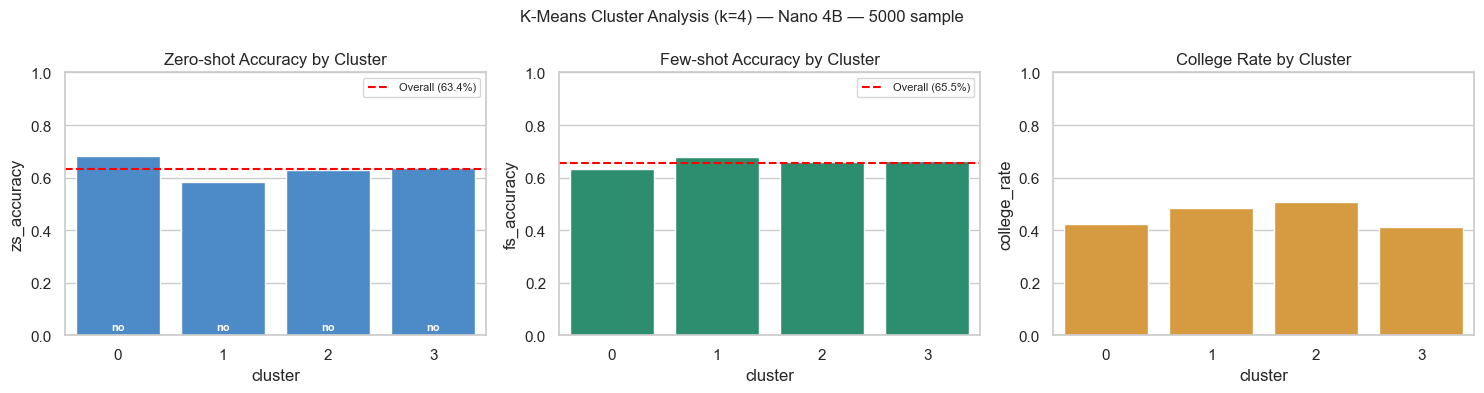

Saved: results/week3_cluster_accuracy.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=cluster_df, x="cluster", y="zs_accuracy", color="#378ADD", ax=axes[0])
axes[0].axhline(y=zs_df["correct"].mean(), color="red", linestyle="--",
                label=f'Overall ({zs_df["correct"].mean():.1%})')
axes[0].set_title("Zero-shot Accuracy by Cluster")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
for i, row in cluster_df.iterrows():
    axes[0].text(i, 0.02, row["dominant_verdict"], ha="center",
                 fontsize=8, color="white", fontweight="bold")

sns.barplot(data=cluster_df, x="cluster", y="fs_accuracy", color="#1D9E75", ax=axes[1])
axes[1].axhline(y=fs_df["correct"].mean(), color="red", linestyle="--",
                label=f'Overall ({fs_df["correct"].mean():.1%})')
axes[1].set_title("Few-shot Accuracy by Cluster")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

sns.barplot(data=cluster_df, x="cluster", y="college_rate", color="#EF9F27", ax=axes[2])
axes[2].set_title("College Rate by Cluster")
axes[2].set_ylim(0, 1)

plt.suptitle(f"K-Means Cluster Analysis (k={K}) — Nano 4B — 5000 sample", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week3_cluster_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week3_cluster_accuracy.png")

## 18. Save Results to metrics.csv

In [19]:
metrics_path = f"{RESULTS_DIR}/metrics.csv"
try:
    existing = pd.read_csv(metrics_path)
    existing = existing[existing["week"] != 3]
    updated  = pd.concat([existing, pd.DataFrame(all_results)], ignore_index=True)
except FileNotFoundError:
    updated = pd.DataFrame(all_results)

updated.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")
print()
print(updated[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row", "week"]].to_string(index=False))

Saved: ../results/metrics.csv

                    model  accuracy  macro_f1  auc_roc  ms_per_row  week
Random Forest (100 trees)    0.7709    0.7701   0.8556       0.007     1
                  XGBoost    0.7150    0.7149   0.7812       0.001     1
        Nano 4B zero-shot    0.6339    0.6071   0.6155    3823.400     3
         Nano 4B few-shot    0.6571    0.6557   0.6686    7642.400     3


## 19. Week 3 Summary

